In [42]:
import numpy as np
from scipy.linalg import expm
from scipy.signal import cont2discrete
from matplotlib import pyplot as plt
import control as ct
import scipy.linalg as la
import json
from quadrotor_model import nonlin_quad_dyn

In [43]:
# ABC = np.load('models/hover_linearization.npz')
ABC_learn = np.load('data/ABCD_learned.npz')
ABC_phys = np.load('models/hover_linearization.npz')

Q = np.diag([200, 200, 200,
              50, 50, 50,
              70, 70, 70, 
              50, 50, 50, 
              20, 20, 20, 20])

R = np.diag([10, 10, 10, 10])

V = np.diag([1e-9, 2e-9, 2e-9, 
             3e-9, 3e-9, 3e-9, 
             2e-9, 2e-9, 2e-9, 
             3e-9, 3e-9, 3e-9, 
             1e-9, 1e-9, 1e-9, 1e-9])

W = 2e-7 * np.eye(12)




## Stabilization LQG/PID ##
Stabilize the quadrotor around an equilibrium. I start with plain LQG (Proportional) and then add in an integral over some past time window, and then add in a derivative over some past time window.

In [44]:
def simulate_lqg(
    ABCD,
    Q,
    R,
    V,
    W,
    T,
    integral=False,
    derivative=False,
    perturbation=None,
    int_window=50,
    K_I=1.0,
    K_D=0.5,
    save_path=None,
    title="Simulation of LQG Controller"
):
    A = ABCD["A"]
    B = ABCD["B"]
    C = ABCD["C"]
    D = ABCD["D"] if "D" in ABCD else np.zeros((C.shape[0], B.shape[1]))

    dt = 0.01
    N = int(T/dt) + 1
    ts = np.linspace(0, T, N)

    Ad, Bd, Cd, Dd, _ = cont2discrete((A,B,C,D), dt)

    K, _, _ = ct.dlqr(Ad, Bd, Q, R)
    L, _, _ = ct.dlqe(Ad, np.eye(Ad.shape[0]), Cd, V, W)
    x_act = np.zeros(Ad.shape[0])
    x_act[:12] = 1e-4*np.random.randn(12)
    x_est = np.zeros(Ad.shape[0])
    u = np.zeros(Bd.shape[1])

    xs = np.zeros((Ad.shape[0],N))
    xs_est = np.zeros((Ad.shape[0],N))
    ys = np.zeros((Cd.shape[0],N))
    us = np.zeros((Bd.shape[1],N))

    xs_est_int = np.zeros((Ad.shape[0], int_window))

    xs_to_u = la.block_diag(
        np.ones(3),
        np.ones(3),
        np.ones(3),
        np.concatenate((np.ones(3), np.zeros(Ad.shape[0]-12)))
    )[:Bd.shape[1], :Ad.shape[0]]

    if perturbation is None:
        us_pert = np.zeros((Bd.shape[1],N))
    else:
        us_pert = perturbation.copy()

    xs[:,0] = x_act
    xs_est[:,0] = x_est
    ys[:,0] = Cd @ x_act + np.random.multivariate_normal(np.zeros(Cd.shape[0]), W)

    for k in range(N-1):

        # Kalman predict/update
        x_pred = Ad @ x_est + Bd @ u
        y = Cd @ x_act + np.random.multivariate_normal(np.zeros(Cd.shape[0]), W)
        y_pred = Cd @ x_pred
        e = y - y_pred
        x_est = x_pred + L @ e

        # rolling state history
        xs_est_int = np.roll(xs_est_int, -1, axis=1)
        xs_est_int[:,-1] = x_est

        # control terms
        u_int = K_I*(xs_to_u @ xs_est_int @ np.ones(int_window))/int_window
        u_der = K_D*np.mean(np.diff(xs_est_int,axis=1),axis=1)[:Bd.shape[1]]

        u = (
            -K @ x_est
            - int(integral)*u_int
            - int(derivative)*u_der
            + us_pert[:,k]
        )

        # plant
        w = np.random.multivariate_normal(np.zeros(Ad.shape[0]), V)
        x_act = Ad @ x_act + Bd @ u + 0*w

        xs[:,k+1] = x_act
        xs_est[:,k+1] = x_est
        ys[:,k+1] = y
        us[:,k+1] = u

    # plotting
    plt.figure()
    plt.plot(ts, ys[0,:], label="x")
    plt.plot(ts, ys[1,:], label="y")
    plt.plot(ts, ys[2,:], label="z")
    plt.legend()
    plt.title(title)
    plt.xlabel("time (s)")
    plt.ylabel("position")

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

    return ts, xs, xs_est, ys, us

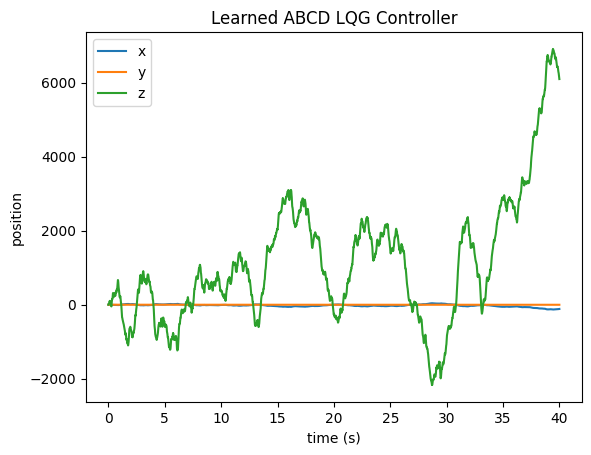

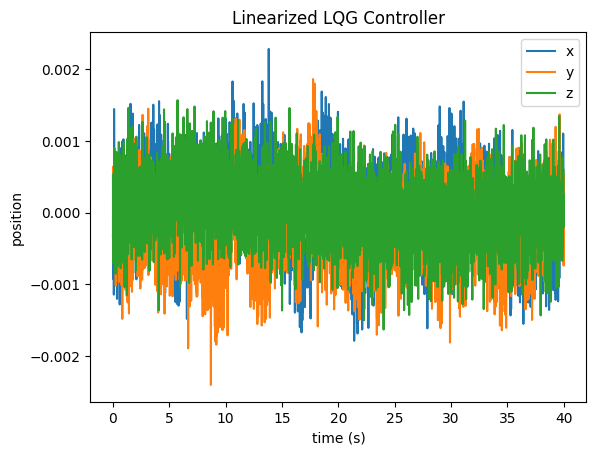

In [45]:
# Plain LQG controller
_ = simulate_lqg(ABC_learn, Q, R, V, W, 40, False, False, title="Learned ABCD LQG Controller", save_path="figures/plain_lqg_learned.png")
_ = simulate_lqg(ABC_phys, Q, R, V, W, 40, False, False, title="Linearized LQG Controller", save_path="figures/plain_lqg_phys.png")

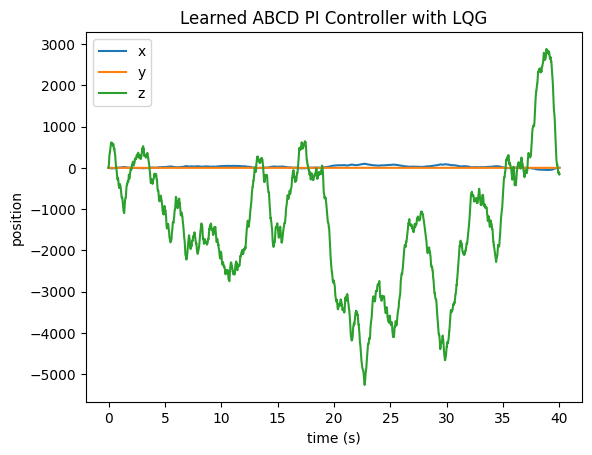

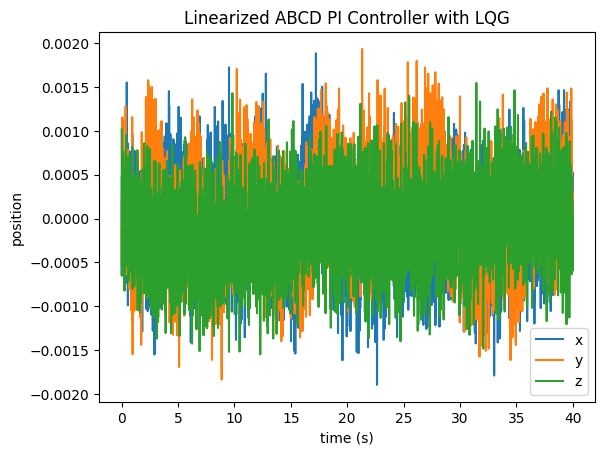

In [46]:
# LQG controller with integral
_ = simulate_lqg(ABC_learn, Q, R, V, W, 40, True, False, K_I=1/25, title="Learned ABCD PI Controller with LQG", save_path='figures/pi_lqg_learned.png')
_ = simulate_lqg(ABC_phys, Q, R, V, W, 40, True, False, K_I=1/25, title="Linearized ABCD PI Controller with LQG", save_path='figures/pi_lqg_phys.png')

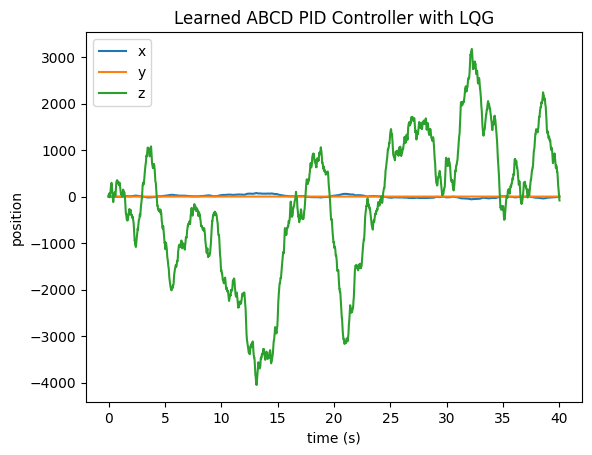

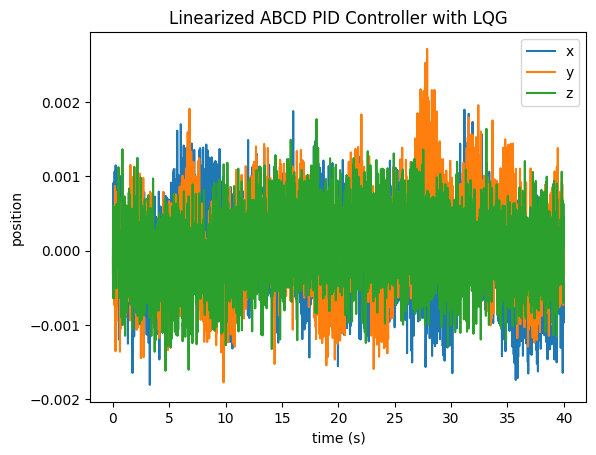

In [47]:
# LQG controller with integral and derivative
_ = simulate_lqg(ABC_learn, Q, R, V, W, 40, True, True, int_window=60, K_I=1/20, title="Learned ABCD PID Controller with LQG", save_path='figures/pid_lqg_learn.png')
_ = simulate_lqg(ABC_phys, Q, R, V, W, 40, True, True, int_window=60, K_I=1/20, title="Linearized ABCD PID Controller with LQG", save_path='figures/pid_lqg_phys.png')

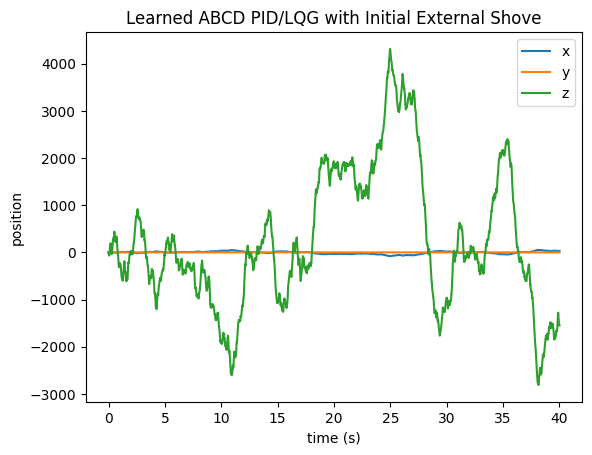

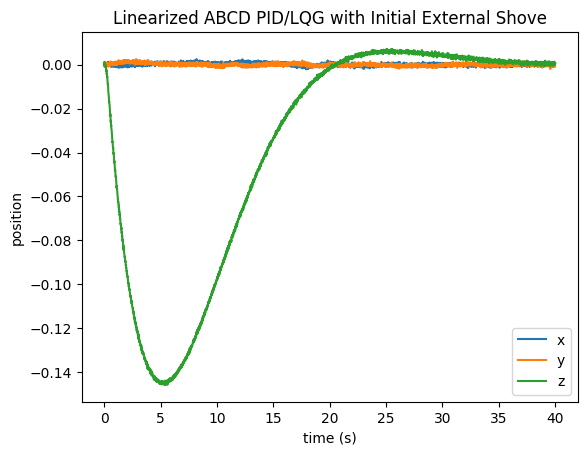

In [48]:
T = 40
u_pert = np.zeros((4, int(T / 0.01)))
u_pert[:, :30] = 10.0
_ = simulate_lqg(ABC_learn, Q, R, V, W, T, True, True, u_pert, K_I=1/25, save_path="figures/pid_lqg_with_pert_learned.png", title="Learned ABCD PID/LQG with Initial External Shove")
_ = simulate_lqg(ABC_phys, Q, R, V, W, T, True, True, u_pert, K_I=1/25, save_path="figures/pid_lqg_with_pert_phys.png", title="Linearized ABCD PID/LQG with Initial External Shove")

In [49]:
def simulate_lqg_forget(
    ABCD,
    Q,
    R,
    V,
    W,
    T,
    integral=False,
    derivative=False,
    perturbation=None,
    int_window=50,
    K_I=1.0,
    K_D=0.5,
    save_path=None,
    title="Simulation of LQG Controller"
):
    A = ABCD["A"]
    B = ABCD["B"]
    C = ABCD["C"]
    D = ABCD["D"] if "D" in ABCD else np.zeros((C.shape[0], B.shape[1]))

    dt = 0.01
    N = int(T/dt) + 1
    ts = np.linspace(0, T, N)

    Ad, Bd, Cd, Dd, _ = cont2discrete((A,B,C,D), dt)

    K, _, _ = ct.dlqr(Ad, Bd, Q, R)
    L, _, _ = ct.dlqe(Ad, np.eye(Ad.shape[0]), Cd, V, W)

    x_act = np.zeros(Ad.shape[0])
    x_act[:12] = 1e-4*np.random.randn(12)
    x_est = np.zeros(Ad.shape[0])
    u = np.zeros(Bd.shape[1])

    xs = np.zeros((Ad.shape[0],N))
    xs_est = np.zeros((Ad.shape[0],N))
    ys = np.zeros((Cd.shape[0],N))
    us = np.zeros((Bd.shape[1],N))

    xs_est_int = np.zeros((Ad.shape[0], int_window))

    xs_to_u = la.block_diag(
        np.ones(3),
        np.ones(3),
        np.ones(3),
        np.concatenate((np.ones(3), np.zeros(Ad.shape[0]-12)))
    )[:Bd.shape[1], :Ad.shape[0]]

    if perturbation is None:
        us_pert = np.zeros((Bd.shape[1],N))
    else:
        us_pert = perturbation.copy()

    xs[:,0] = x_act
    xs_est[:,0] = x_est
    ys[:,0] = Cd @ x_act + np.random.multivariate_normal(np.zeros(Cd.shape[0]), W)

    delay = 30

    for k in range(N-1):

        x_ref = np.zeros_like(x_est)
        x_ref[:3] = xs_est_int[:3, -delay]   # only shift position target

        x_pred = Ad @ x_est + Bd @ u
        y = Cd @ x_act + np.random.multivariate_normal(np.zeros(Cd.shape[0]), W)
        y_pred = Cd @ x_pred
        e = y - y_pred
        x_est = x_pred + L @ e

        xs_est_int = np.roll(xs_est_int, -1, axis=1)
        xs_est_int[:, -1] = x_est

        x_err = x_est - x_ref

        u_int = K_I * (xs_to_u @ (xs_est_int - x_ref[:, None]) @ np.ones(int_window)) / int_window
        u_der = K_D * np.mean(np.diff(xs_est_int, axis=1), axis=1)[:Bd.shape[1]]

        u = (
            -K @ x_err
            + int(integral) * u_int
            + int(derivative) * u_der
            + us_pert[:, k]
        )

        w = np.random.multivariate_normal(np.zeros(Ad.shape[0]), V)
        x_act = Ad @ x_act + Bd @ u + w

        xs[:, k+1] = x_act
        xs_est[:, k+1] = x_est
        ys[:, k+1] = y
        us[:, k+1] = u
    # plotting
    plt.figure()
    plt.plot(ts, ys[0,:], label="x")
    plt.plot(ts, ys[1,:], label="y")
    plt.plot(ts, ys[2,:], label="z")
    plt.legend()
    plt.title(title)
    plt.xlabel("time (s)")
    plt.ylabel("position")

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

    return ts, xs, xs_est, ys, us

## Relinquishing Position

Now let's make it "forget where it is" and just try to come to rest at some point in the near future. We could try to accomplish this simply by tuning Q so that the position punishment is extremely small, but that doesn't work because actuation doesn't directly enter through position. Instead we can just blind the controller a bit and make it only see a few steps away. If we throw it hard again, we get this:

/var/folders/91/kky1gfj53pn7zwgtrbwn6llh0000gn/T/ipykernel_15374/1984025938.py:81: RuntimeWarning: overflow encountered in matmul
  -K @ x_err
/var/folders/91/kky1gfj53pn7zwgtrbwn6llh0000gn/T/ipykernel_15374/1984025938.py:67: RuntimeWarning: invalid value encountered in matmul
  y = Cd @ x_act + np.random.multivariate_normal(np.zeros(Cd.shape[0]), W)
/var/folders/91/kky1gfj53pn7zwgtrbwn6llh0000gn/T/ipykernel_15374/1984025938.py:68: RuntimeWarning: invalid value encountered in matmul
  y_pred = Cd @ x_pred
/var/folders/91/kky1gfj53pn7zwgtrbwn6llh0000gn/T/ipykernel_15374/1984025938.py:88: RuntimeWarning: invalid value encountered in matmul
  x_act = Ad @ x_act + Bd @ u + w


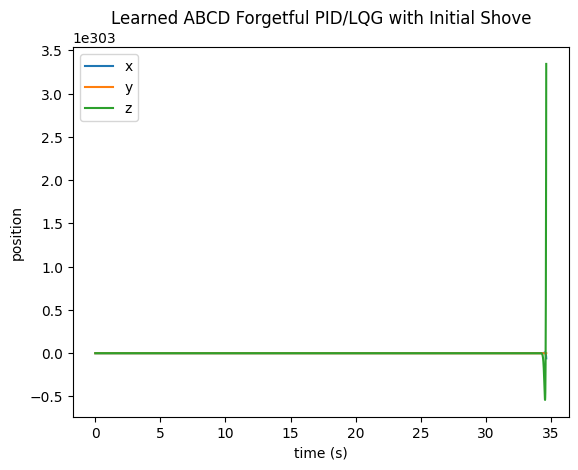

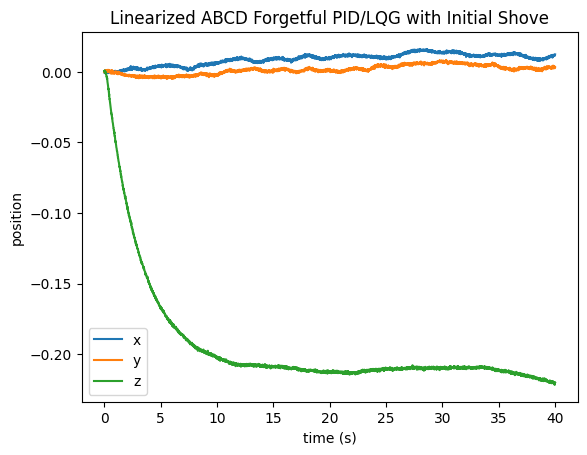

In [50]:
T = 40
u_pert = np.zeros((4, int(T / 0.01)))
u_pert[:, :30] = 10.0
_ = simulate_lqg_forget(ABC_learn, Q, R, V, W, T, True, True, u_pert, K_I=1/25, save_path="figures/forgetful_pid_lqg_with_pert_learn.png", title="Learned ABCD Forgetful PID/LQG with Initial Shove")
_ = simulate_lqg_forget(ABC_phys, Q, R, V, W, T, True, True, u_pert, K_I=1/25, save_path="figures/forgetful_pid_lqg_with_pert_phys.png", title="Linearized ABCD Forgetful PID/LQG with Initial Shove")